In [ ]:
import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('notebook')

CONV_DIR = '../examples/comparisons/closed_boundary_DIIID/convergence'
BF_DIR   = '../examples/comparisons/closed_boundary_DIIID/brute_force'

rows = []
for folder in sorted(os.listdir(CONV_DIR)):
    rpath = os.path.join(CONV_DIR, folder, 'results.json')
    if not os.path.isfile(rpath):
        continue
    m = re.match(r'lambda:([^,]+),coils:(\d+)', folder)
    if not m:
        continue
    with open(rpath) as f:
        data = json.load(f)

    lbfgs = data['methods'].get('Multi-start L-BFGS')
    bayes = data['methods'].get('Bayesian')
    if not lbfgs or not bayes or 'n_bayesian_evals' not in bayes:
        continue

    n_bo    = int(bayes['n_bayesian_evals'])
    bo_best = float(min(bayes['convergence_history'][:n_bo]))

    rows.append({
        'coils':             int(m.group(2)),
        'lambda':            float(m.group(1)),
        'lbfgs_cost':        lbfgs['best_cost'],
        'lbfgs_evals':       lbfgs['n_evals'],
        'lbfgs_starts':      lbfgs['starts_completed'],
        'bayes_nr_cost':     bo_best,
        'bayes_nr_evals':    n_bo,
        'bayes_full_cost':   bayes['best_cost'],
        'bayes_full_evals':  bayes['n_evals'],
        'bf_cost':           data.get('brute_force_cost', float('nan')),
    })

df = pd.DataFrame(rows)
df['lbfgs_calls_per_start'] = df['lbfgs_evals'] / df['lbfgs_starts']
print(f"Loaded {len(df)} configs")

Loaded 35 configs


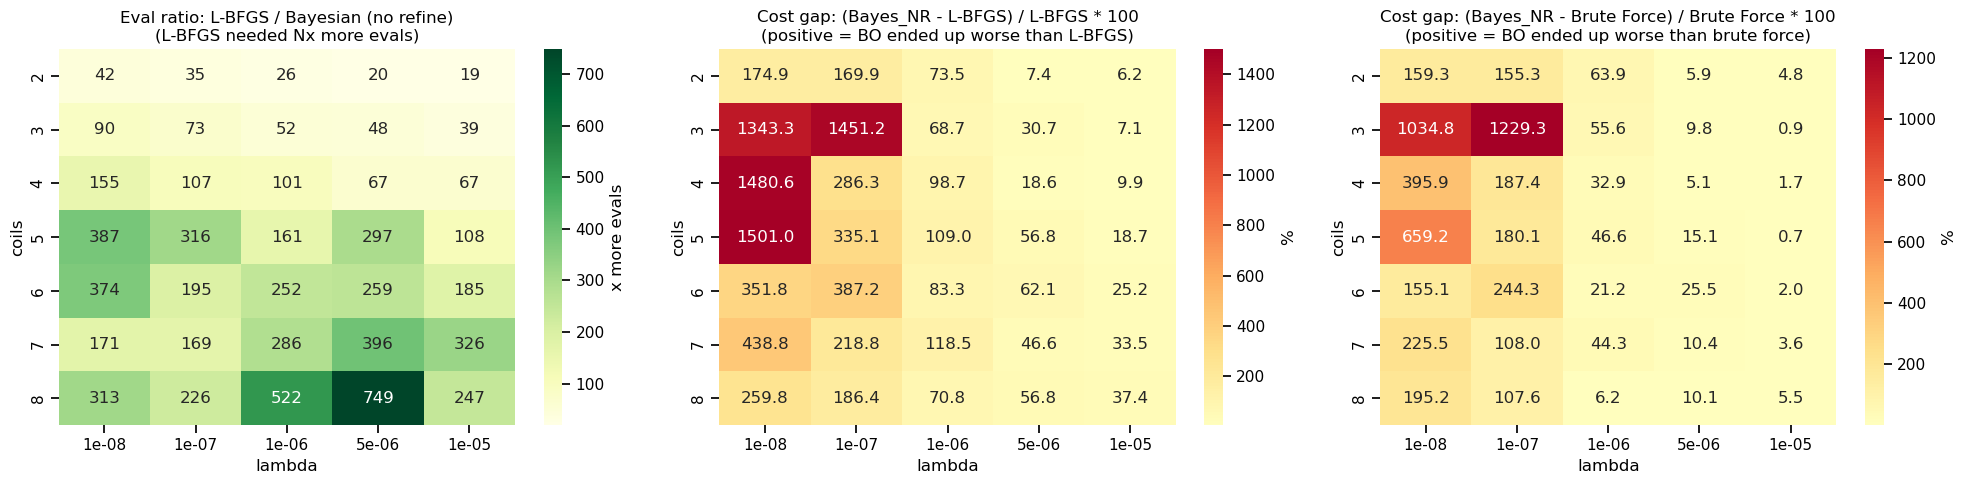

In [27]:
df['eval_ratio']       = df['lbfgs_evals'] / df['bayes_nr_evals']
df['cost_gap_lbfgs']   = (df['bayes_nr_cost'] - df['lbfgs_cost']) / df['lbfgs_cost'] * 100
df['cost_gap_bf']      = (df['bayes_nr_cost'] - df['bf_cost'])    / df['bf_cost']    * 100

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- left: eval ratio ---
pivot_evals = df.pivot_table(index='coils', columns='lambda', values='eval_ratio')
pivot_evals = pivot_evals.reindex(sorted(pivot_evals.columns), axis=1)
sns.heatmap(
    pivot_evals, annot=True, fmt='.0f', cmap='YlGn',
    ax=axes[0],
    cbar_kws={'label': 'x more evals'}
)
axes[0].set_title('Eval ratio: L-BFGS / Bayesian (no refine)\n(L-BFGS needed Nx more evals)')
axes[0].set_xlabel('lambda')
axes[0].set_ylabel('coils')

# --- middle: cost gap vs L-BFGS ---
pivot_lbfgs = df.pivot_table(index='coils', columns='lambda', values='cost_gap_lbfgs')
pivot_lbfgs = pivot_lbfgs.reindex(sorted(pivot_lbfgs.columns), axis=1)
sns.heatmap(
    pivot_lbfgs, annot=True, fmt='.1f', cmap='RdYlGn_r',
    ax=axes[1], center=0,
    cbar_kws={'label': '%'}
)
axes[1].set_title('Cost gap: (Bayes_NR - L-BFGS) / L-BFGS * 100\n(positive = BO ended up worse than L-BFGS)')
axes[1].set_xlabel('lambda')
axes[1].set_ylabel('coils')

# --- right: cost gap vs brute force ---
pivot_bf = df.pivot_table(index='coils', columns='lambda', values='cost_gap_bf')
pivot_bf = pivot_bf.reindex(sorted(pivot_bf.columns), axis=1)
sns.heatmap(
    pivot_bf, annot=True, fmt='.1f', cmap='RdYlGn_r',
    ax=axes[2], center=0,
    cbar_kws={'label': '%'}
)
axes[2].set_title('Cost gap: (Bayes_NR - Brute Force) / Brute Force * 100\n(positive = BO ended up worse than brute force)')
axes[2].set_xlabel('lambda')
axes[2].set_ylabel('coils')

plt.tight_layout()
plt.show()

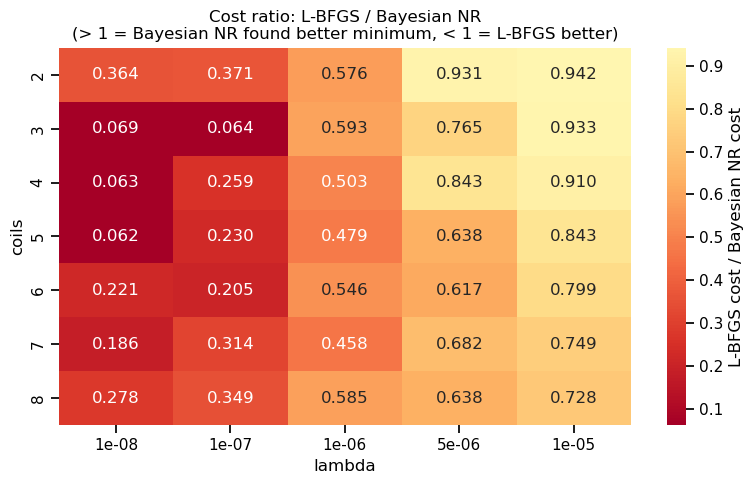

In [28]:
# ratio > 1: L-BFGS cost is higher (Bayesian NR found better minimum)
# ratio < 1: Bayesian NR cost is higher (L-BFGS found better minimum)
df['cost_ratio'] = df['lbfgs_cost'] / df['bayes_nr_cost']

pivot_ratio = df.pivot_table(index='coils', columns='lambda', values='cost_ratio')
pivot_ratio = pivot_ratio.reindex(sorted(pivot_ratio.columns), axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot_ratio, annot=True, fmt='.3f', cmap='RdYlGn',
    ax=ax, center=1.0,
    cbar_kws={'label': 'L-BFGS cost / Bayesian NR cost'}
)
ax.set_title('Cost ratio: L-BFGS / Bayesian NR\n(> 1 = Bayesian NR found better minimum, < 1 = L-BFGS better)')
ax.set_xlabel('lambda')
ax.set_ylabel('coils')
plt.tight_layout()
plt.show()

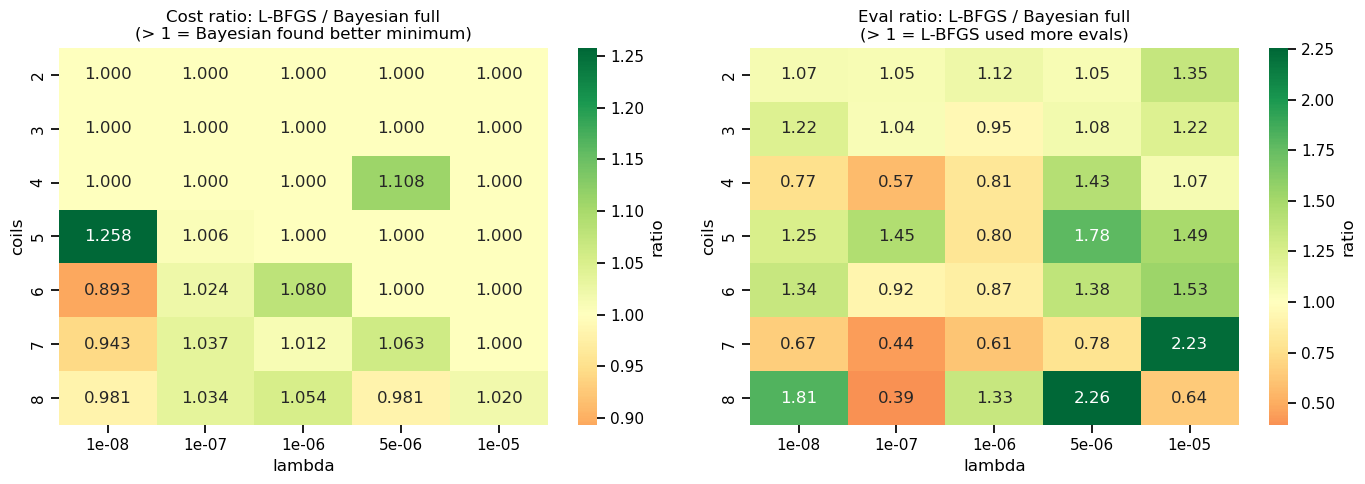

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: cost ratio ---
# > 1: L-BFGS cost higher (Bayesian full better)
# < 1: Bayesian full cost higher (L-BFGS better)
pivot_cost = df.pivot_table(index='coils', columns='lambda',
                            values='lbfgs_cost').divide(
              df.pivot_table(index='coils', columns='lambda',
                             values='bayes_full_cost'))
pivot_cost = pivot_cost.reindex(sorted(pivot_cost.columns), axis=1)
sns.heatmap(pivot_cost, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=axes[0], center=1.0,
            cbar_kws={'label': 'ratio'})
axes[0].set_title('Cost ratio: L-BFGS / Bayesian full\n(> 1 = Bayesian found better minimum)')
axes[0].set_xlabel('lambda')
axes[0].set_ylabel('coils')

# --- right: eval ratio ---
# > 1: L-BFGS used more evals
# < 1: Bayesian full used more evals
pivot_evals = df.pivot_table(index='coils', columns='lambda',
                             values='lbfgs_evals').divide(
               df.pivot_table(index='coils', columns='lambda',
                              values='bayes_full_evals'))
pivot_evals = pivot_evals.reindex(sorted(pivot_evals.columns), axis=1)
sns.heatmap(pivot_evals, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[1], center=1.0,
            cbar_kws={'label': 'ratio'})
axes[1].set_title('Eval ratio: L-BFGS / Bayesian full\n(> 1 = L-BFGS used more evals)')
axes[1].set_xlabel('lambda')
axes[1].set_ylabel('coils')

plt.tight_layout()
plt.show()

In [30]:
pivot = df.pivot_table(index='coils', columns='lambda', values='bayes_nr_evals')
pivot = pivot.reindex(sorted(pivot.columns), axis=1)
pivot.columns = [f'{c:.2e}' for c in pivot.columns]
pivot.index.name = 'coils \\ lambda'
display(pivot.astype(int).style.set_caption('Bayesian (no refinement): function calls'))

,1.00e-08,1.00e-07,1.00e-06,5.00e-06,1.00e-05
coils \ lambda,,,,,
2,307,307,307,316,342
3,307,307,314,345,355
4,341,307,307,394,346
5,307,307,307,307,355
6,307,307,307,307,340
7,307,307,307,307,437
8,307,307,307,307,370


In [31]:
pivot_lbfgs = df.pivot_table(index='coils', columns='lambda', values='lbfgs_calls_per_start')
pivot_lbfgs = pivot_lbfgs.reindex(sorted(pivot_lbfgs.columns), axis=1)
pivot_lbfgs.columns = [f'{c:.2e}' for c in pivot_lbfgs.columns]
pivot_lbfgs.index.name = 'coils \\ lambda'
display(pivot_lbfgs.round(0).astype(int).style.set_caption('L-BFGS: avg function calls per start'))

,1.00e-08,1.00e-07,1.00e-06,5.00e-06,1.00e-05
coils \ lambda,,,,,
2,250,209,156,122,125
3,533,431,316,278,263
4,839,631,594,511,437
5,886,782,913,785,641
6,991,892,1292,1186,897
7,873,999,1598,1687,1270
8,991,1259,2137,2299,1726
